<a href="https://colab.research.google.com/github/lalit2909/Multimodal-RAG-updated-with-agentic-AI/blob/main/SalaryPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Save model
import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Salary_Data.csv to Salary_Data (1).csv


In [ ]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 4912


In [ ]:
print("Total number of rows:", len(df))

Total number of rows: 6704


In [ ]:
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


In [ ]:
print("Total number of rows:", len(df))


Total number of rows: 1792


In [ ]:
print(df.shape[0])

1792


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1792
Columns: 6


In [ ]:
df.isnull().sum()

,0
Age,1
Gender,1
Education Level,2
Job Title,1
Years of Experience,2
Salary,4


In [ ]:
df = df.dropna()

In [ ]:
print(df.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [ ]:
# Check null values before cleaning
print("Null values before cleaning:")
print(df.isnull().sum())

# Remove rows with null values
df.dropna(inplace=True)

# Check null values after cleaning
print("\nNull values after cleaning:")
print(df.isnull().sum())

# Check dataset size after cleaning
print("\nDataset Shape:", df.shape)

Null values before cleaning:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

Null values after cleaning:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

Dataset Shape: (1787, 6)


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
Index(['Age', 'Years of Experience', 'Salary'], dtype='object')

Categorical columns:
Index(['Gender', 'Education Level', 'Job Title'], dtype='object')


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (1787, 6)

Column Names:
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 1787 entries, 0 to 6631
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1787 non-null   float64
 1   Gender               1787 non-null   object 
 2   Education Level      1787 non-null   object 
 3   Job Title            1787 non-null   object 
 4   Years of Experience  1787 non-null   float64
 5   Salary               1787 non-null   float64
dtypes: float64(3), object(3)
memory usage: 97.7+ KB

Statistical Summary:


,Age,Years of Experience,Salary
count,1787.000000,1787.000000,1787.000000
mean,35.139899,9.156128,113184.659765
std,8.213045,6.844924,51596.536766
min,21.000000,0.000000,350.000000
25%,29.000000,3.000000,70000.000000
50%,33.000000,8.000000,110000.000000
75%,41.000000,13.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) > 0:
    missing.plot(kind='bar')
    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.show()
else:
    print("No missing values found.")

No missing values found.


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


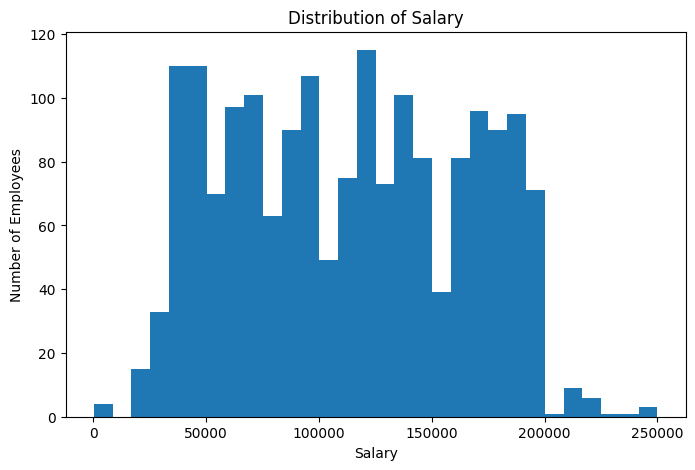

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Salary'], bins=30)

plt.title("Distribution of Salary")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()

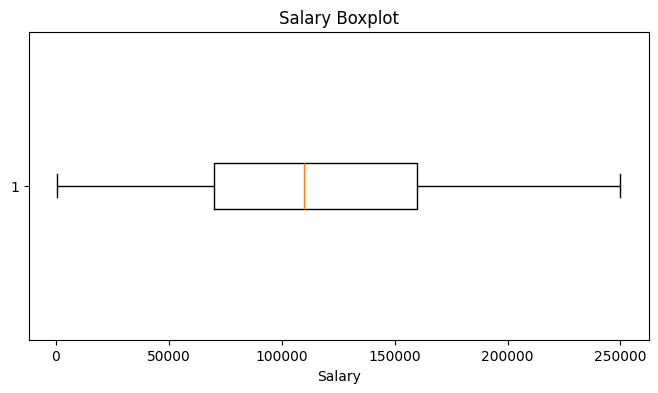

In [ ]:
plt.figure(figsize=(8,4))

plt.boxplot(df['Salary'].dropna(), vert=False)

plt.title("Salary Boxplot")
plt.xlabel("Salary")

plt.show()

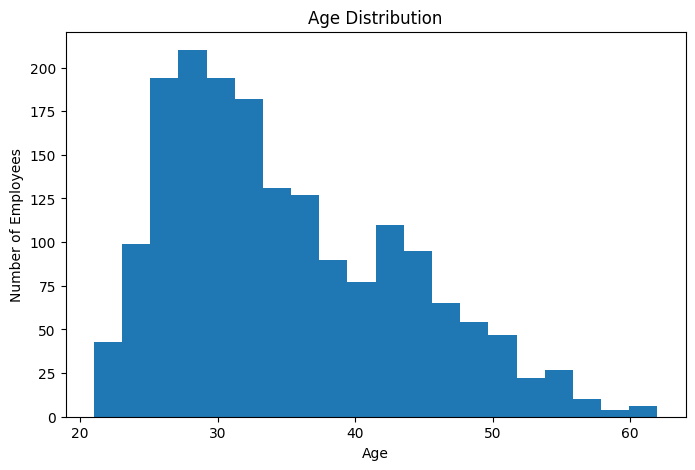

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

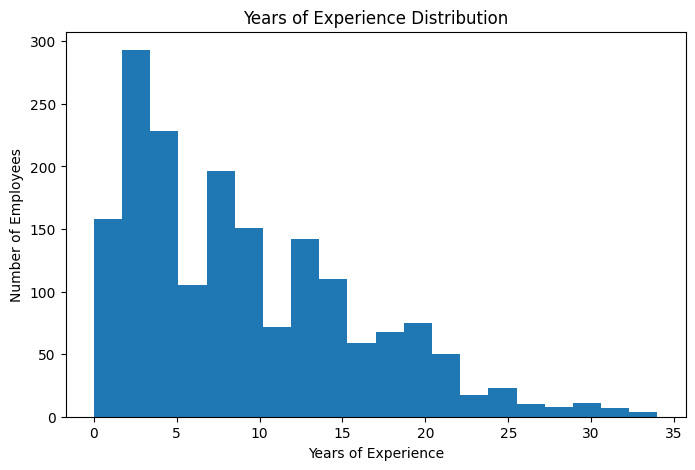

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Years of Experience'], bins=20)

plt.title("Years of Experience Distribution")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Employees")

plt.show()

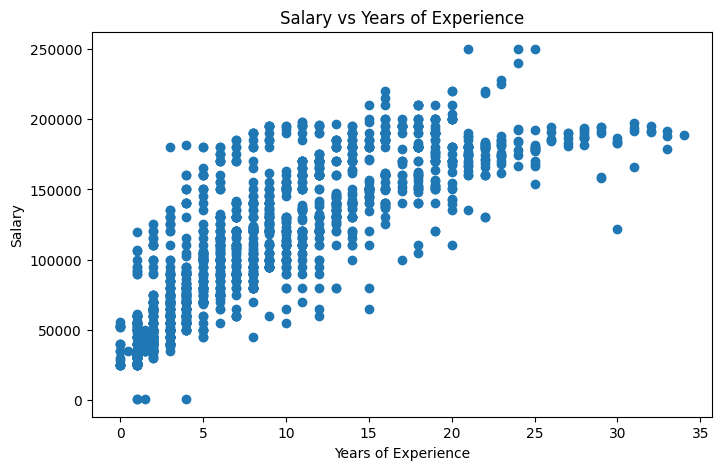

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df['Years of Experience'], df['Salary'])

plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

In [ ]:
print(df['Years of Experience'].corr(df['Salary']))

0.818724842566649


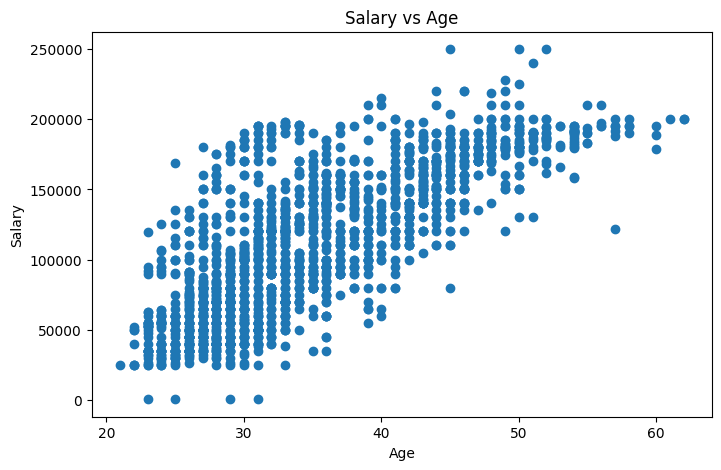

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df['Age'], df['Salary'])

plt.title("Salary vs Age")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()

In [ ]:
print("EDA SUMMARY")
print("=" * 40)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nAverage Salary:", df['Salary'].mean())
print("Median Salary:", df['Salary'].median())

print("\nAverage Experience:", df['Years of Experience'].mean())
print("Average Age:", df['Age'].mean())

print("\nCorrelation between Experience and Salary:",
      df['Years of Experience'].corr(df['Salary']))

EDA SUMMARY
Number of rows: 1787
Number of columns: 6
Missing values: 0
Duplicate rows: 0

Average Salary: 113184.65976496923
Median Salary: 110000.0

Average Experience: 9.156127588136542
Average Age: 35.139899272523785

Correlation between Experience and Salary: 0.818724842566649


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Salary', axis=1)
y = df['Salary']

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Check the sizes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1429, 5)
Testing data: (358, 5)


In [ ]:
print("X_train:", len(X_train))
print("X_test:", len(X_test))
print("y_train:", len(y_train))
print("y_test:", len(y_test))

X_train: 1429
X_test: 358
y_train: 1429
y_test: 358


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Separate features and target
X = df.drop('Salary', axis=1)
y = df['Salary']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Numerical columns:", numerical_cols.tolist())
print("Categorical columns:", categorical_cols.tolist())

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# One-hot encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Transform training and testing data
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train_encoded, y_train)

# Make predictions
y_pred = model.predict(X_test_encoded)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Numerical columns: ['Age', 'Years of Experience']
Categorical columns: ['Gender', 'Education Level', 'Job Title']

Model Performance
-------------------------
MAE : 15790.974089571946
MSE : 459360944.7435139
RMSE: 21432.70735916286
R²  : 0.832346367711754


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Regression Performance")
print("----------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Regression Performance
----------------------
MAE  : 15790.974089571946
MSE  : 459360944.7435139
RMSE : 21432.70735916286
R²   : 0.832346367711754


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report